In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

email_data = pd.read_csv('/content/drive/MyDrive/FYPDataset/final_email_category_balanced.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
email_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242379 entries, 0 to 242378
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   From              242379 non-null  object 
 1   To                235681 non-null  object 
 2   Subject           235589 non-null  object 
 3   Message           242378 non-null  object 
 4   Day               242379 non-null  object 
 5   Date & Time       242379 non-null  object 
 6   url_count         242379 non-null  int64  
 7   Cleaned_Subject   227561 non-null  object 
 8   Cleaned_Message   241774 non-null  object 
 9   Combined_Text     242379 non-null  object 
 10  Qwen2.5_Category  242379 non-null  object 
 11  Log_Body_Length   242379 non-null  float64
 12  avg_url_category  242379 non-null  float64
dtypes: float64(2), int64(1), object(10)
memory usage: 24.0+ MB


In [ ]:
email_data['Qwen2.5_Category'].value_counts()

,count
Qwen2.5_Category,
General Business Communication,55924
Finance & Transactions,35682
Personal Communication & Purely Personal,29053
Meeting & Scheduling,21720
IT Alerts & System Notifications,20000
Spam,20000
Legal & Contractual,20000
Project Management & Strategy,20000
Internal Policies & HR Updates,20000


In [ ]:
email_data.columns

Index(['From', 'To', 'Subject', 'Message', 'Day', 'Date & Time', 'url_count',
       'Cleaned_Subject', 'Cleaned_Message', 'Combined_Text',
       'Qwen2.5_Category', 'Log_Body_Length', 'avg_url_category'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Encode the target
le = LabelEncoder()
email_data['Category_Label'] = le.fit_transform(email_data['Qwen2.5_Category'])

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(email_data['Category_Label']),
    y=email_data['Category_Label']
)

# Map weights to class index
weights_dict = dict(enumerate(class_weights))
print("Class weights:", weights_dict)

Class weights: {0: np.float64(0.7547502942660165), 1: np.float64(0.48156426578928546), 2: np.float64(1.34655), 3: np.float64(1.34655), 4: np.float64(1.34655), 5: np.float64(1.2399171270718232), 6: np.float64(0.9269610711458369), 7: np.float64(1.34655), 8: np.float64(1.34655)}


In [ ]:
# Use this to map category names to labels for reference
for i, label in enumerate(le.classes_):
    print(f"{i}: {label}")

0: Finance & Transactions
1: General Business Communication
2: IT Alerts & System Notifications
3: Internal Policies & HR Updates
4: Legal & Contractual
5: Meeting & Scheduling
6: Personal Communication & Purely Personal
7: Project Management & Strategy
8: Spam


In [ ]:
import scipy
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english'
    )
X_tfidf = tfidf.fit_transform(email_data['Combined_Text'])

numeric_features = email_data[['Log_Body_Length', 'avg_url_category']]
scaler = StandardScaler()
X_numeric = scaler.fit_transform(numeric_features)
X_numeric_sparse = scipy.sparse.csr_matrix(X_numeric)

from scipy.sparse import hstack
X_final = hstack([X_tfidf, X_numeric_sparse])
y = email_data['Category_Label']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

# SVM

Column: Combined_Text
✅ Accuracy: 0.7746513738757324
SVM - Classification Report:
                                          precision    recall  f1-score   support

                  Finance & Transactions       0.69      0.69      0.69      7136
          General Business Communication       0.70      0.60      0.65     11185
        IT Alerts & System Notifications       0.93      0.93      0.93      4000
          Internal Policies & HR Updates       0.97      0.94      0.96      4000
                     Legal & Contractual       0.65      0.79      0.71      4000
                    Meeting & Scheduling       0.72      0.79      0.75      4344
Personal Communication & Purely Personal       0.71      0.80      0.75      5811
           Project Management & Strategy       0.92      0.86      0.89      4000
                                    Spam       0.95      0.93      0.94      4000

                                accuracy                           0.77     48476
              

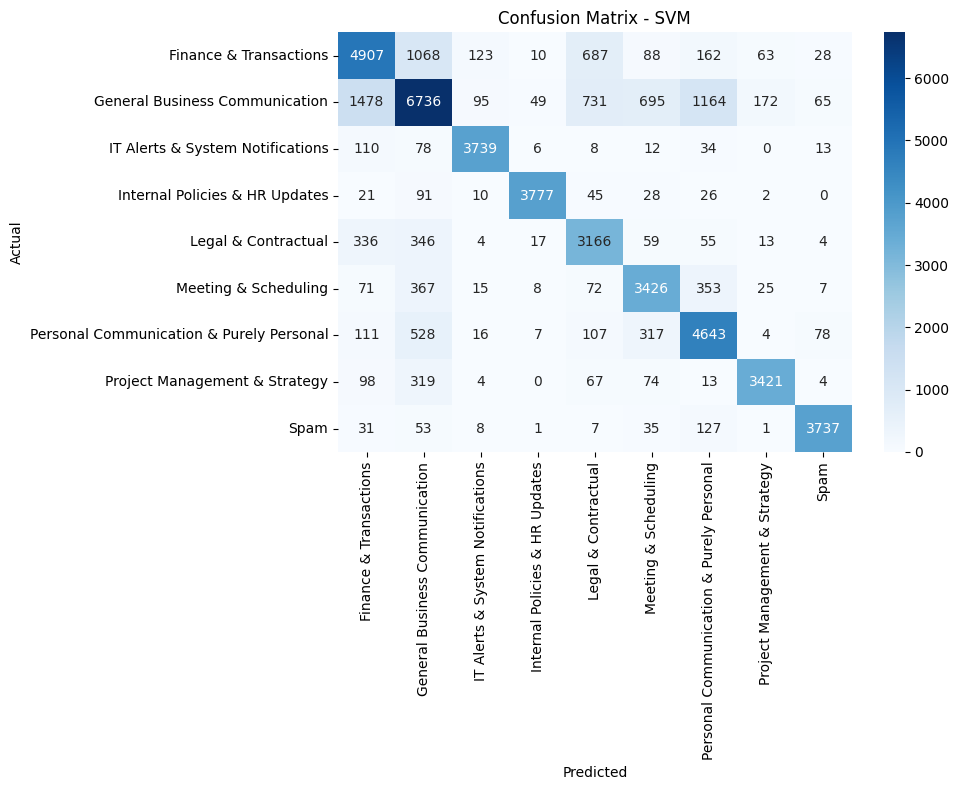

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Train SVM classifier
svm_model = LinearSVC(class_weight='balanced', max_iter=5000, dual=False)
svm_model.fit(X_train, y_train)

# Predict and Evaluate
y_pred = svm_model.predict(X_test)

print("Column: Combined_Text")
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print(f"SVM - Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
conf_matrix = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=le.classes_,
    columns=le.classes_
)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import joblib

model_path = '/content/drive/MyDrive/category models/svm_category_model.joblib'

# Save the model
joblib.dump(svm_model, model_path)

print(f"✅ Model saved to: {model_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model saved to: /content/drive/MyDrive/category models/svm_category_model.joblib


In [ ]:
# Sample email input
test_subject = "Someone added you as their recovery email"
test_message = "Alert: If you don’t recognize this account, it’s likely your email address was added in error. You can remove your email address from that account."

# Combine like your training data
test_combined = test_subject + " " + test_message

# TF-IDF transform
X_test_tfidf = tfidf.transform([test_combined])

# Numeric features
import numpy as np

log_body_length = np.log1p(len(test_message))
avg_url_category = 0  # or use category average, or just set a default mean

# Scale numeric features
X_test_numeric = scaler.transform([[log_body_length, avg_url_category]])
X_test_numeric_sparse = scipy.sparse.csr_matrix(X_test_numeric)

# Combine both
X_test_final = scipy.sparse.hstack([X_test_tfidf, X_test_numeric_sparse])

# Predict the label
pred_label_num = svm_model.predict(X_test_final)[0]

# Decode back to category name
pred_category = le.inverse_transform([pred_label_num])[0]

print("📥 Input Subject:", test_subject)
print("📬 Input Message:", test_message)
print("📌 Predicted Category:", pred_category)

In [ ]:
# Sample email input
test_subject = "Someone added you as their recovery email"
test_message = "If you don’t recognize this account, it’s likely your email address was added in error. You can remove your email address from that account."

# Combine subject and message
test_combined = test_subject + " " + test_message

# TF-IDF transformation (only)
X_test_tfidf = tfidf.transform([test_combined])

# Predict using only TF-IDF features
pred_label_num = svm_model.predict(X_test_tfidf)[0]

# Decode predicted label
pred_category = le.inverse_transform([pred_label_num])[0]

# Output
print("📥 Input Subject:", test_subject)
print("📬 Input Message:", test_message)
print("📌 Predicted Category:", pred_category)

📥 Input Subject: Someone added you as their recovery email
📬 Input Message: If you don’t recognize this account, it’s likely your email address was added in error. You can remove your email address from that account.
📌 Predicted Category: Personal Communication & Purely Personal


In [ ]:
# Sample email input
test_subject = "Urgent: "
test_message = "fuck you bitch come fuck me"

# Combine subject and message
test_combined = test_subject + " " + test_message

# TF-IDF transformation (only)
X_test_tfidf = tfidf.transform([test_combined])

# Predict using only TF-IDF features
pred_label_num = svm_model.predict(X_test_tfidf)[0]

# Decode predicted label
pred_category = le.inverse_transform([pred_label_num])[0]

# Output
print("📥 Input Subject:", test_subject)
print("📬 Input Message:", test_message)
print("📌 Predicted Category:", pred_category)

📥 Input Subject: Urgent: 
📬 Input Message: fuck you bitch come fuck me
📌 Predicted Category: Personal Communication & Purely Personal


# Linear Regression

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Column: Combined_Text
✅ Accuracy: 0.7750226916412245
Logistic Regression - Classification Report:
                                          precision    recall  f1-score   support

                  Finance & Transactions       0.69      0.70      0.69      7136
          General Business Communication       0.72      0.58      0.64     11185
        IT Alerts & System Notifications       0.93      0.93      0.93      4000
          Internal Policies & HR Updates       0.98      0.94      0.96      4000
                     Legal & Contractual       0.64      0.81      0.71      4000
                    Meeting & Scheduling       0.72      0.80      0.76      4344
Personal Communication & Purely Personal       0.70      0.81      0.75      5811
           Project Management & Strategy       0.91      0.87      0.89      4000
                                    Spam       0.95      0.93      0.94      4000

                                accuracy                           0.78     4847

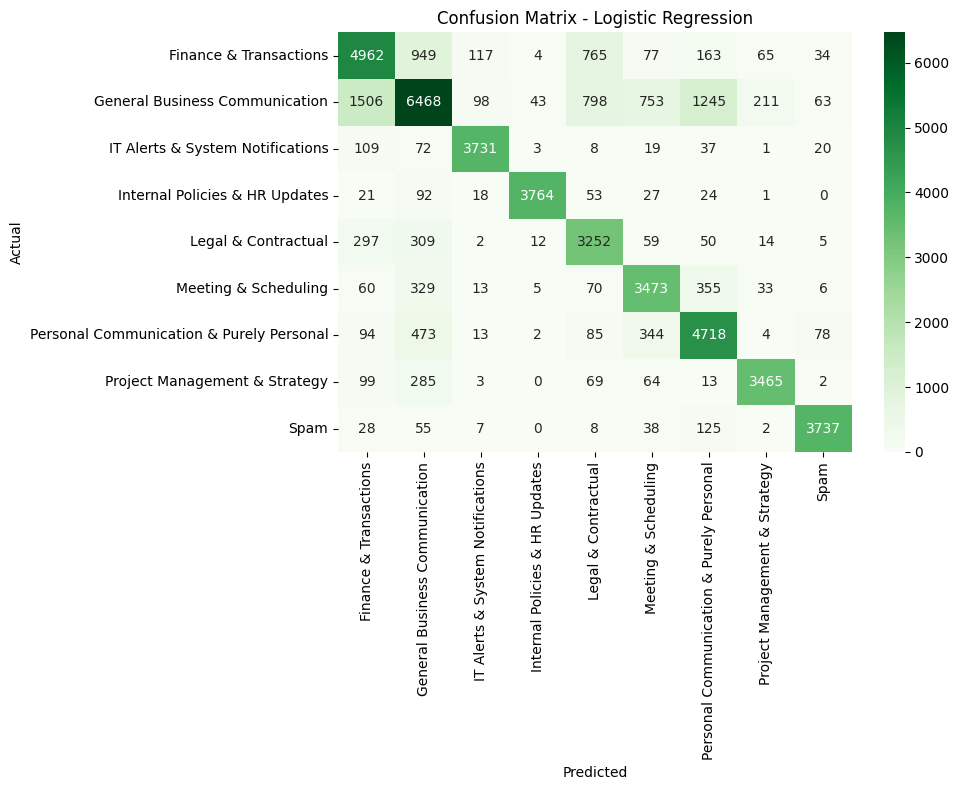

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Train the logistic regression model for multi-class classification
lr_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=5000
)
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)

# Evaluation
print("Column: Combined_Text")
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic Regression - Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
conf_matrix = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=le.classes_,
    columns=le.classes_
)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [ ]:
# Sample email input
test_subject = "Sprint Planning for Project Phoenix"
test_message = "Let’s finalize the backlog and sprint priorities for the next two weeks."

# Combine subject and message
test_combined = test_subject + " " + test_message

# TF-IDF transformation (only)
X_test_tfidf = tfidf.transform([test_combined])

# Predict using only TF-IDF features
pred_label_num = lr_model.predict(X_test_tfidf)[0]

# Decode predicted label
pred_category = le.inverse_transform([pred_label_num])[0]

# Output
print("📥 Input Subject:", test_subject)
print("📬 Input Message:", test_message)
print("📌 Predicted Category:", pred_category)

📥 Input Subject: Sprint Planning for Project Phoenix
📬 Input Message: Let’s finalize the backlog and sprint priorities for the next two weeks.
📌 Predicted Category: Project Management & Strategy


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import joblib

model_path = '/content/drive/MyDrive/category models/lr_category_model.joblib'

# Save the model
joblib.dump(lr_model, model_path)

print(f"✅ Model saved to: {model_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model saved to: /content/drive/MyDrive/category models/lr_category_model.joblib


# Random Forest

Column: Combined_Text
✅ Accuracy: 0.7756415545837115
Random Forest - Classification Report:
                                          precision    recall  f1-score   support

                  Finance & Transactions       0.74      0.62      0.67      7136
          General Business Communication       0.61      0.74      0.67     11185
        IT Alerts & System Notifications       0.96      0.91      0.94      4000
          Internal Policies & HR Updates       0.99      0.94      0.96      4000
                     Legal & Contractual       0.72      0.69      0.70      4000
                    Meeting & Scheduling       0.78      0.76      0.77      4344
Personal Communication & Purely Personal       0.73      0.76      0.74      5811
           Project Management & Strategy       0.97      0.83      0.90      4000
                                    Spam       0.97      0.93      0.95      4000

                                accuracy                           0.78     48476
    

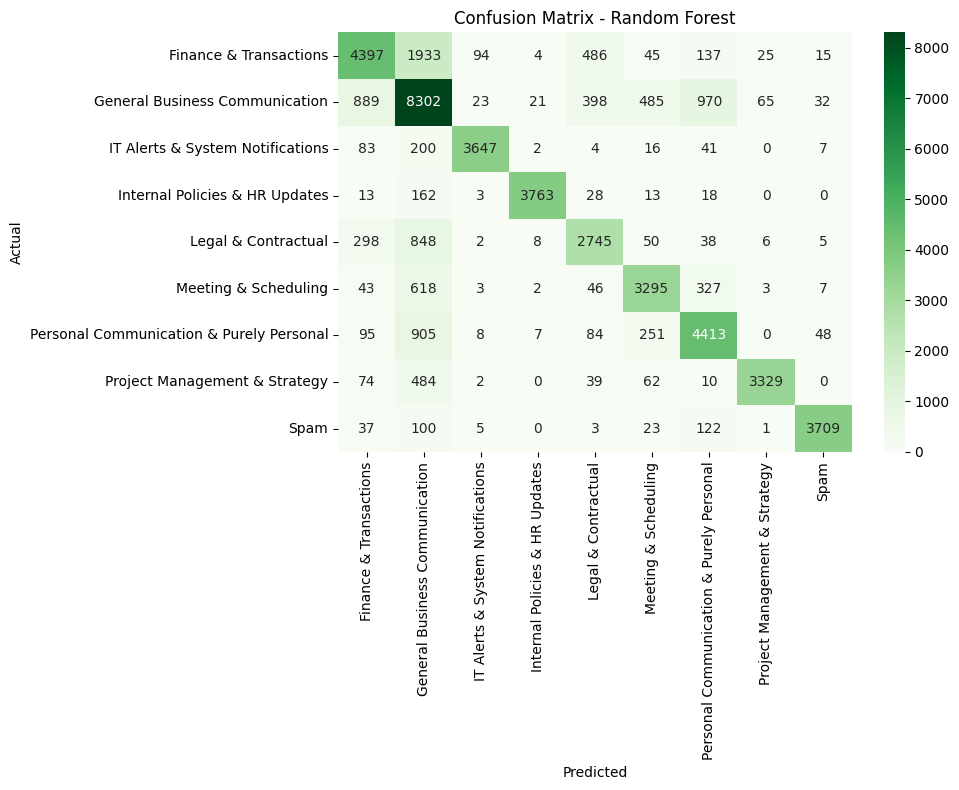

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Column: Combined_Text")
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest - Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

conf_matrix = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=le.classes_,
    columns=le.classes_
)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [ ]:
# Sample email input
test_subject = "Sprint Planning for Project Phoenix"
test_message = "Let’s finalize the backlog and sprint priorities for the next two weeks."

# Combine subject and message
test_combined = test_subject + " " + test_message

# TF-IDF transformation (only)
X_test_tfidf = tfidf.transform([test_combined])

# Predict using only TF-IDF features
pred_label_num = rf_model.predict(X_test_tfidf)[0]

# Decode predicted label
pred_category = le.inverse_transform([pred_label_num])[0]

# Output
print("📥 Input Subject:", test_subject)
print("📬 Input Message:", test_message)
print("📌 Predicted Category:", pred_category)

📥 Input Subject: Sprint Planning for Project Phoenix
📬 Input Message: Let’s finalize the backlog and sprint priorities for the next two weeks.
📌 Predicted Category: General Business Communication


Wrong

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import joblib

model_path = '/content/drive/MyDrive/category models/rf_category_model.joblib'

joblib.dump(rf_model, model_path)

print(f"✅ Model saved to: {model_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model saved to: /content/drive/MyDrive/category models/rf_category_model.joblib


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:14:31] WARNING: /workspace/src/context.cc:43: No visible GPU is found, setting device to CPU.
  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:14:31] WARNING: /workspace/src/context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)


Column: Combined_Text
✅ Accuracy: 0.7648527106196881
XGBoost (GPU) - Classification Report:
                                          precision    recall  f1-score   support

                  Finance & Transactions       0.73      0.59      0.65      7136
          General Business Communication       0.59      0.76      0.66     11185
        IT Alerts & System Notifications       0.96      0.92      0.94      4000
          Internal Policies & HR Updates       0.99      0.94      0.96      4000
                     Legal & Contractual       0.71      0.70      0.71      4000
                    Meeting & Scheduling       0.78      0.72      0.75      4344
Personal Communication & Purely Personal       0.74      0.68      0.71      5811
           Project Management & Strategy       0.96      0.84      0.90      4000
                                    Spam       0.97      0.92      0.95      4000

                                accuracy                           0.76     48476
    

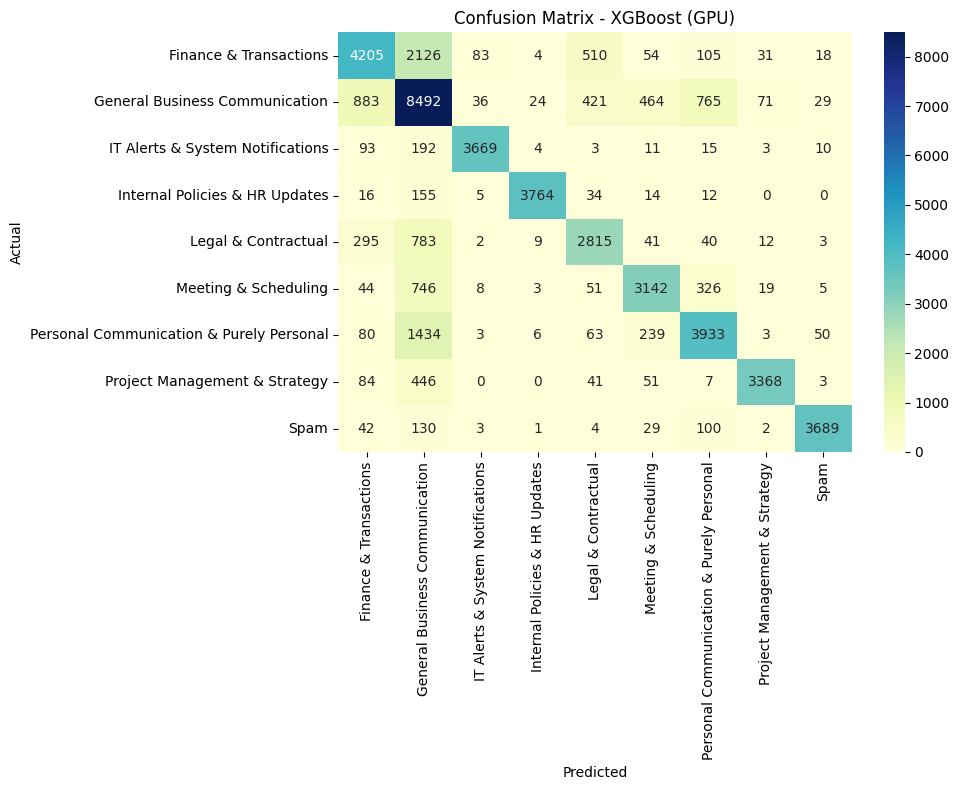

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

xgb_model = XGBClassifier(
    n_estimators=100,
    eval_metric='mlogloss',
    tree_method='hist',
    device='cuda',
    random_state=42
)


# Fit the model
xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_test)

# Print results
print("Column: Combined_Text")
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("XGBoost (GPU) - Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
conf_matrix = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=le.classes_,
    columns=le.classes_
)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion Matrix - XGBoost (GPU)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [ ]:
# Sample email input
test_subject = "Sprint Planning for Project Phoenix"
test_message = "Let’s finalize the backlog and sprint priorities for the next two weeks."

# Combine subject and message
test_combined = test_subject + " " + test_message

# TF-IDF transformation (only)
X_test_tfidf = tfidf.transform([test_combined])

# Predict using only TF-IDF features
pred_label_num = xgb_model.predict(X_test_tfidf)[0]

# Decode predicted label
pred_category = le.inverse_transform([pred_label_num])[0]

# Output
print("📥 Input Subject:", test_subject)
print("📬 Input Message:", test_message)
print("📌 Predicted Category:", pred_category)

📥 Input Subject: Sprint Planning for Project Phoenix
📬 Input Message: Let’s finalize the backlog and sprint priorities for the next two weeks.
📌 Predicted Category: Project Management & Strategy


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import joblib

model_path = '/content/drive/MyDrive/category models/xgb_category_model.joblib'

joblib.dump(xgb_model, model_path)

print(f"✅ Model saved to: {model_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model saved to: /content/drive/MyDrive/category models/xgb_category_model.joblib


# Naive Bayes

Column: Combined_Text
✅ Accuracy: 0.7216148197045961
Naive Bayes - Classification Report:
                                          precision    recall  f1-score   support

                  Finance & Transactions       0.73      0.45      0.56      7136
          General Business Communication       0.52      0.78      0.62     11185
        IT Alerts & System Notifications       0.90      0.89      0.89      4000
          Internal Policies & HR Updates       1.00      0.92      0.96      4000
                     Legal & Contractual       0.63      0.62      0.62      4000
                    Meeting & Scheduling       0.79      0.59      0.68      4344
Personal Communication & Purely Personal       0.71      0.73      0.72      5811
           Project Management & Strategy       0.99      0.80      0.88      4000
                                    Spam       0.99      0.85      0.91      4000

                                accuracy                           0.72     48476
      

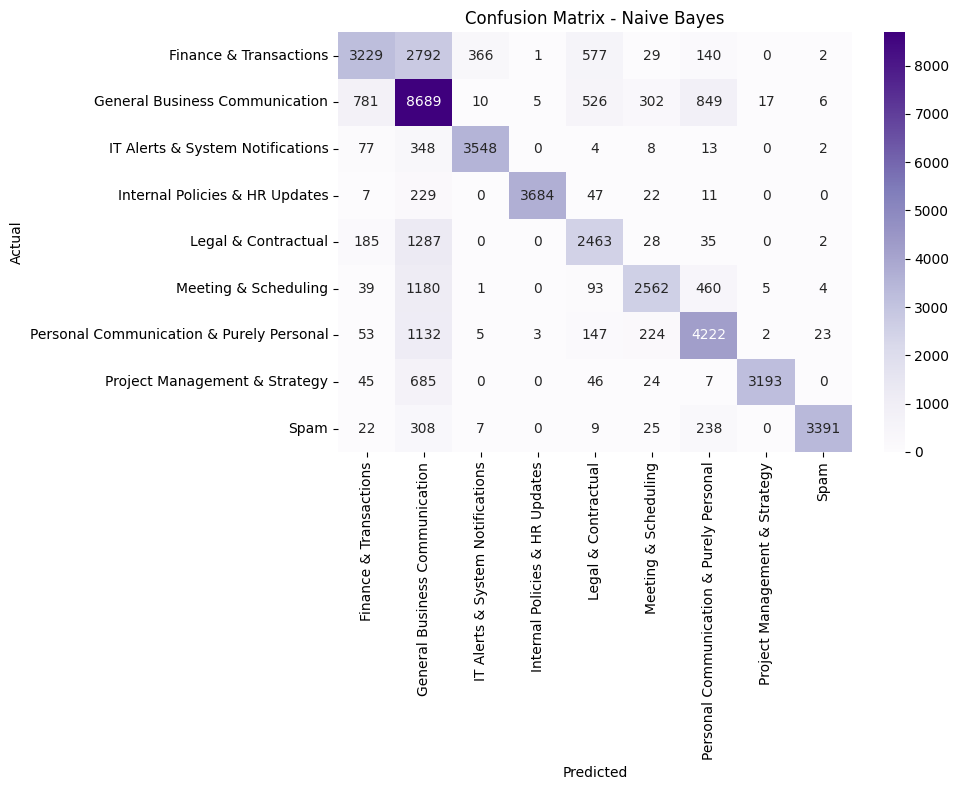

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialize Naive Bayes
nb_model = MultinomialNB()

# Fit the model
nb_model.fit(X_train, y_train)

# Predict
y_pred = nb_model.predict(X_test)

# Print results
print("Column: Combined_Text")
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("Naive Bayes - Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
conf_matrix = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=le.classes_,
    columns=le.classes_
)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix - Naive Bayes")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [ ]:
# Sample email input
test_subject = "Sprint Planning for Project Phoenix"
test_message = "Let’s finalize the backlog and sprint priorities for the next two weeks."

# Combine subject and message
test_combined = test_subject + " " + test_message

# TF-IDF transformation (only)
X_test_tfidf = tfidf.transform([test_combined])

# Predict using only TF-IDF features
pred_label_num = nb_model.predict(X_test_tfidf)[0]

# Decode predicted label
pred_category = le.inverse_transform([pred_label_num])[0]

# Output
print("📥 Input Subject:", test_subject)
print("📬 Input Message:", test_message)
print("📌 Predicted Category:", pred_category)

📥 Input Subject: Sprint Planning for Project Phoenix
📬 Input Message: Let’s finalize the backlog and sprint priorities for the next two weeks.
📌 Predicted Category: Project Management & Strategy


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import joblib

model_path = '/content/drive/MyDrive/category models/nb_category_model.joblib'

joblib.dump(nb_model, model_path)

print(f"✅ Model saved to: {model_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model saved to: /content/drive/MyDrive/category models/nb_category_model.joblib
